# **Analisis Exploratorio de Metrobus**

1. Introducción

2. Objetivos

3. Importación de librerías

4. Configuración de Pandas

5. Carga de datos

6. Resumen general
    - dimensiones
    - memoria
    - nulos
    - duplicados

7. Análisis individual

    * 7.1 Viajes
    * 7.2 Mantenimiento
    * 7.3 Incidencias
    * 7.4 Conductores
    * 7.5 Cocheras
    * 7.6 Líneas
    * 7.7 Paradas
    * 7.8 Tarifas
    * 7.9 Vehículos

8. Calidad del dato
    - nulos
    - duplicados
    - tipos
    - cardinalidad
    - inconsistencias

9. Relaciones entre tablas

10. Hipótesis iniciales

11. Conclusiones

## **1. Introducción**

## **2. Objetivos**

## **3. Importación de librerías**

In [222]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **4. Configuración de Pandas**

In [223]:
# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

# Mostrar todo el texto en las celdas sin truncar
pd.set_option('display.max_colwidth', None)

## **5. Carga de datos**

In [224]:
# Cargamos los archivos CSV en los DataFrames

# Tablas de hechos
df_viajes = pd.read_csv("data/fact_viajes.csv").set_index('viaje_id')
df_incidencias = pd.read_csv("data/fact_incidencias.csv").set_index('incidencia_id')
df_mantenimientos = pd.read_csv("data/fact_mantenimiento.csv").set_index('mantenimiento_id')

# Tablas de dimensión
df_lineas = pd.read_csv("data/dim_linea.csv").set_index('linea_id')
df_vehiculos = pd.read_csv("data/dim_vehiculo.csv").set_index('vehiculo_id')
df_conductores = pd.read_csv("data/dim_conductor.csv").set_index('conductor_id')
df_paradas = pd.read_csv("data/dim_parada.csv").set_index('parada_id')
df_tarifas = pd.read_csv("data/dim_tarifa.csv").set_index('tarifa_id')
df_cocheras = pd.read_csv("data/dim_depot.csv").set_index('depot_id')

## **6. Resumen general**

En este apartado analizamos la estructura de cada tabla para identificar:

* Total de columnas
* Total de filas
* Total de nulos
* Porcentaje de nulos
* Total de duplicados
* Memoria utilizada

In [225]:
# Obtenemos un nuevo DataFrame con los metadatos de todos los datasets
dataframes = {
    "viajes": df_viajes,
    "incidencias": df_incidencias,
    "mantenimiento": df_mantenimientos,
    "lineas": df_lineas,
    "vehiculos": df_vehiculos,
    "conductores": df_conductores,
    "paradas": df_paradas,
    "tarifas": df_tarifas,
    "cocheras": df_cocheras
}

In [226]:
metadatos = {
    'DataFrame': [],
    'Columnas': [],
    'Filas': [],
    'Nulos': [],
    '% Nulos': [],
    'Duplicados': [],
    'Memoria MB': []
}

for name, dataframe in dataframes.items():
    nulos = dataframe.isnull().sum().sum()
    filas = dataframe.shape[0]

    metadatos["DataFrame"].append(name)
    metadatos["Columnas"].append(dataframe.shape[1])
    metadatos["Filas"].append(filas)
    metadatos["Nulos"].append(nulos)
    metadatos["% Nulos"].append(round(((nulos/filas) * 100), 2))
    metadatos["Duplicados"].append(dataframe.duplicated().sum())
    metadatos["Memoria MB"].append(round(dataframe.memory_usage(deep=True).sum() / (1024 **2), 3))

df_estructura_general = pd.DataFrame(metadatos).set_index('DataFrame')
df_estructura_general

,Columnas,Filas,Nulos,% Nulos,Duplicados,Memoria MB
DataFrame,,,,,,
viajes,23,50000,1105,2.21,0,22.212
incidencias,15,4000,0,0.00,0,1.378
mantenimiento,14,876,15,1.71,0,0.317
lineas,6,10,0,0.00,0,0.002
vehiculos,11,45,1,2.22,0,0.010
conductores,9,30,1,3.33,0,0.008
paradas,9,120,2,1.67,0,0.029
tarifas,5,9,0,0.00,0,0.001
cocheras,5,3,0,0.00,0,0.000


## **7. Análisis individual**

En este apartado se realiza un análisis individual de cada tabla del dataset con el objetivo de comprender su estructura, calidad y distribución de los datos.

Para cada columna se analizan los siguientes aspectos:

* Tipo de dato de cada atributo.
* Número total de valores nulos.
* Porcentaje de valores nulos respecto al total de registros.
* Cantidad de valores únicos para conocer la cardinalidad de los datos.
* Moda de cada columna para identificar los valores más repetidos.
* Número total de filas y columnas de cada tabla.
* Valor más frecuente (`top`) y su frecuencia (`freq`) de aparición.
* Medidas estadísticas descriptivas para variables numéricas:
  * Media.
  * Desviación estándar.
  * Moda
  * Valor mínimo.
  * Valor máximo.

Este análisis permite detectar problemas de calidad de datos, identificar posibles valores atípicos y comprender la distribución de las variables antes de realizar las transformaciones y análisis posteriores.

In [227]:
def es_numero(columna):
    return columna.dtype in [int, float, bool]

def es_object(columna):
    return columna.dtype in [object, str]

def pasar_int_a_str(lista):
    return [str(n) for n in lista]

# TODO NO FUNCIONA EN LAS TABLAS LINEAS NI COCHERAS


In [ ]:
def obtener_valores(columna):
    return columna.dropna().unique()[:3]

In [229]:
def calcular_nulos(columna):
    return columna.isnull().sum()

def calcular_porcentaje_nulos(columna):
    return round((calcular_nulos(columna)/ columna.size) * 100, 2)

def calcular_valores_unicos(columna):
    return len(columna.unique())

def calcular_top(columna):
    return columna.value_counts().index[0] if es_object(columna) else np.nan

def calcular_frecuencia(columna):
    return columna.value_counts().iloc[0] if es_object(columna) else np.nan

def calcular_media(columna):
    return round( np.mean(columna), 2) if es_numero(columna) else np.nan

def calcular_std(columna):
    return round(np.std(columna), 2) if es_numero(columna) else np.nan

def calcular_moda(columna):
    lista_con_str = pasar_int_a_str(list(columna.mode())[:6])
    resultado = " - ".join(lista_con_str) + " - ..." if len(lista_con_str) > 5 else ("".join(lista_con_str) if len(lista_con_str) == 1 else " - ".join(lista_con_str))
    
    return resultado if es_numero(columna) else np.nan

def calcular_min(columna):
    return columna.min() if es_numero(columna) else np.nan

def calcular_max(columna):
    return columna.max() if es_numero(columna) else np.nan

In [230]:
def crear_tabla_metadatos(df):

    return pd.DataFrame(
                data= {
                        'Columna': df.columns,
                        'Tipo_Dato': df.dtypes,
                        'Valores_Nulos': df.apply(calcular_nulos, axis=0), 
                        'Porcentaje_Nulos': df.apply(calcular_porcentaje_nulos, axis=0),
                        'Valores_Unicos': df.apply(calcular_valores_unicos, axis=0),
                        'Filas': df.shape[0],
                        'Columnas': df.shape[1],
                        'Media': df.apply(calcular_media, axis=0),
                        'Desviacion': df.apply(calcular_std, axis=0),
                        'Moda': df.apply(calcular_moda, axis=0),
                        'Minimo': df.apply(calcular_min, axis=0),
                        'Maximo': df.apply(calcular_max, axis=0),
                        'Top': df.apply(calcular_top, axis=0),
                        'Frecuencia_Moda': df.apply(calcular_frecuencia, axis=0),
                        'Ejemplo de Valores (Max.3)': df.apply(obtener_valores, axis=0)

                }).set_index('Columna').sort_values(by='Tipo_Dato')  # Ordena las columnas por tipo de dato para agrupar los valores estadísticos válidos y evitar la alternancia entre valores y NaN.

### **7.1 Viajes**

In [231]:
df_viajes.head(3)

,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,es_festivo,franja_horaria,hora_salida_prog,hora_salida_real,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
viaje_id,,,,,,,,,,,,,,,,,,,,,,,
1,4,2,2,17,116,2023-08-14,2023,8,Monday,False,Tarde punta,17:50,18:09,19:22,19,73,78.0,0.609,14.1,14.1,True,4.69,4
2,4,3,3,5,48,2024-05-20,2024,5,Monday,False,Manana punta,07:10,07:23,08:30,13,67,115.0,0.885,14.1,14.1,True,5.86,2
3,5,4,4,33,110,2023-08-15,2023,8,Tuesday,False,Valle manana,12:30,12:30,13:05,0,35,47.0,0.362,7.3,7.3,True,3.15,3


In [232]:
df_viajes_metadatos = crear_tabla_metadatos(df_viajes)
df_viajes_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
viaje_completado,bool,0,0.00,2,50000,23,0.98,0.14,True,False,True,NaN,NaN,"[True, False]"
es_festivo,bool,0,0.00,2,50000,23,0.28,0.45,False,False,True,NaN,NaN,"[False, True]"
linea_id,int64,0,0.00,10,50000,23,5.50,2.87,7,1,10,NaN,NaN,"[4, 5, 2]"
duracion_real_min,int64,0,0.00,105,50000,23,62.60,23.85,39,25,129,NaN,NaN,"[73, 67, 35]"
retraso_salida_min,int64,0,0.00,55,50000,23,3.89,6.76,0,-99,50,NaN,NaN,"[19, 13, 0]"
mes,int64,0,0.00,12,50000,23,6.52,3.45,8,1,12,NaN,NaN,"[8, 5, 3]"
tarifa_predominante_id,int64,0,0.00,9,50000,23,3.61,2.16,3,1,9,NaN,NaN,"[4, 2, 3]"
parada_destino_id,int64,0,0.00,80,50000,23,80.45,23.13,104,41,120,NaN,NaN,"[116, 48, 110]"
parada_origen_id,int64,0,0.00,40,50000,23,20.55,11.56,28,1,40,NaN,NaN,"[17, 5, 33]"


In [233]:
df_viajes.dia_semana.unique()

array(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday',
       'Saturday', 'SATURDAY', 'SUNDAY', 'FRIDAY', 'TUESDAY', 'WEDNESDAY',
       'MONDAY', 'THURSDAY'], dtype=object)

In [234]:
df_viajes['dia_semana'].value_counts()

dia_semana
Thursday     7259
Tuesday      7250
Monday       7189
Wednesday    7109
Sunday       7066
Saturday     7057
Friday       7040
FRIDAY          6
THURSDAY        6
SUNDAY          5
TUESDAY         5
WEDNESDAY       4
SATURDAY        3
MONDAY          1
Name: count, dtype: int64

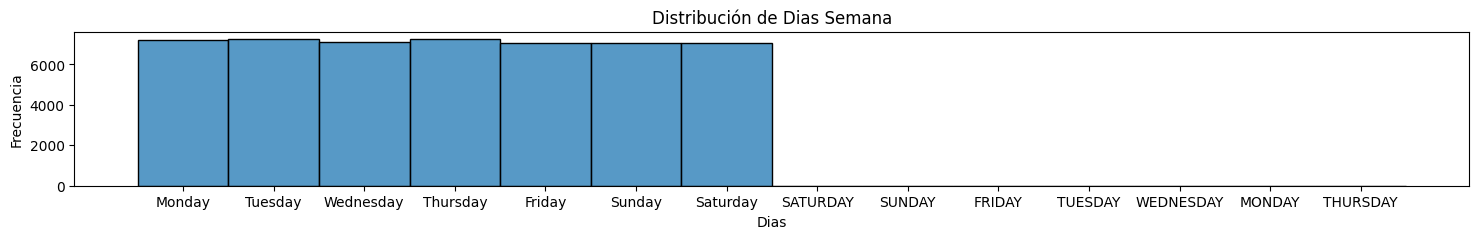

In [235]:
plt.figure(figsize=(18, 2))
sns.histplot(df_viajes['dia_semana'])
plt.title("Distribución de Dias Semana")
plt.xlabel("Dias")
plt.ylabel("Frecuencia")
plt.show()

In [236]:
df_viajes[ (df_viajes.consumo.isnull())].head(5)

,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,es_festivo,franja_horaria,hora_salida_prog,hora_salida_real,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
viaje_id,,,,,,,,,,,,,,,,,,,,,,,
37,3,38,10,29,87,2023-06-28,2023,6,Wednesday,False,Manana punta,06:50,07:19,08:01,29,42,58.0,0.446,9.7,9.7,True,NaN,3
289,9,38,10,6,55,2024-10-13,2024,10,Sunday,True,Tarde punta,20:50,20:56,22:42,6,106,62.0,0.477,19.8,19.8,True,NaN,6
302,9,9,23,15,99,2023-02-28,2023,2,Tuesday,False,Tarde,16:30,16:32,18:18,2,106,15.0,0.120,19.8,19.8,True,NaN,2
315,7,22,8,17,66,2024-05-03,2024,5,Friday,False,Noche,21:50,21:50,22:26,0,36,37.0,0.285,8.9,8.9,True,NaN,3
317,3,24,10,18,112,2022-06-02,2022,6,Thursday,False,Manana punta,08:10,08:12,09:00,2,48,64.0,0.512,9.7,9.7,True,NaN,2


In [237]:
def calcular_media_consumo(df, km_programados, km_recorridos, vehiculo_id):
    df_consumo = df[ (df['km_programados'] == km_programados) & ( df['km_recorridos'] == km_recorridos ) & ( df['vehiculo_id'] == vehiculo_id )]
    return np.mean(df_consumo['consumo'])

# Podemos calcular el consumo del viaje haciendo la media de las filas obtenidas
for indice, fila in df_viajes[ (df_viajes.consumo.isnull())].iterrows():
    df_viajes.loc[ (df_viajes.consumo.isnull()), 'consumo'] = calcular_media_consumo(df_viajes, fila['km_programados'], fila['km_recorridos'], fila['vehiculo_id'] )


In [238]:
# Podemos solucionarlo calculandolo con ocupacion_pct
df_viajes[ (df_viajes.pasajeros_subidos.isnull())].sample(5)

,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,es_festivo,franja_horaria,hora_salida_prog,hora_salida_real,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
viaje_id,,,,,,,,,,,,,,,,,,,,,,,
37507,5,2,16,21,69,2022-10-05,2022,10,Wednesday,False,Manana punta,08:50,09:16,09:46,26,30,NaN,0.898,7.3,7.3,True,3.10,2
36167,5,6,20,32,71,2023-10-09,2023,10,Monday,False,Tarde punta,20:20,20:24,20:57,4,33,NaN,0.811,7.3,7.3,True,2.36,6
13568,6,3,17,17,99,2024-09-30,2024,9,Monday,False,Tarde punta,19:40,19:49,21:35,9,106,NaN,0.946,23.5,23.5,True,10.06,2
17028,6,19,5,19,79,2022-02-01,2022,2,Tuesday,False,Manana punta,08:20,08:26,10:06,6,100,NaN,0.600,23.5,23.5,True,8.08,1
31340,2,9,9,14,70,2023-03-16,2023,3,Thursday,False,Tarde punta,17:40,17:42,18:22,2,40,NaN,0.784,11.2,11.2,True,14.19,3


In [239]:
df_inner = pd.merge(df_viajes[ (df_viajes.pasajeros_subidos.isnull())], df_vehiculos, on='vehiculo_id', how='left')[['ocupacion_pct', 'capacidad_total']]
df_inner['pasajeros_subidos'] = np.round(df_inner['ocupacion_pct'] * df_inner['capacidad_total'])

df_inner.head(3)

,ocupacion_pct,capacidad_total,pasajeros_subidos
0,0.172,180,31.0
1,0.248,125,31.0
2,0.904,125,113.0


In [240]:
df_viajes.loc[ (df_viajes.pasajeros_subidos.isnull()), 'pasajeros_subidos'] = df_inner.pasajeros_subidos


In [241]:
# Fecha es un object no un datetime
df_viajes.fecha = pd.to_datetime(df_viajes.fecha)

In [242]:
df_viajes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 1 to 50000
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   linea_id                50000 non-null  int64         
 1   vehiculo_id             50000 non-null  int64         
 2   conductor_id            50000 non-null  int64         
 3   parada_origen_id        50000 non-null  int64         
 4   parada_destino_id       50000 non-null  int64         
 5   fecha                   50000 non-null  datetime64[ns]
 6   anno                    50000 non-null  int64         
 7   mes                     50000 non-null  int64         
 8   dia_semana              50000 non-null  object        
 9   es_festivo              50000 non-null  bool          
 10  franja_horaria          50000 non-null  object        
 11  hora_salida_prog        50000 non-null  object        
 12  hora_salida_real        50000 non-null  object     

### **7.2 Mantenimiento**

In [243]:
df_mantenimientos.head(3)

,vehiculo_id,depot_id,fecha_entrada,fecha_salida,anno,mes,tipo_mantenimiento,categoria,es_correctivo,dias_fuera_servicio,km_en_revision,coste_eur,proveedor,garantia_meses
mantenimiento_id,,,,,,,,,,,,,,
1,1,1,2024-07-24,2024-07-25,2024,7,Cambio aceite,Preventivo,False,1,278454,218.70,TallerBus Norte,0
2,1,1,2023-02-08,2023-02-09,2023,2,Cambio neumaticos,Preventivo,False,1,240059,1068.93,TallerBus Norte,0
3,1,1,2024-10-28,2024-10-29,2024,10,Cambio neumaticos,Preventivo,False,1,493071,722.19,Taller Oficial Mercedes,0


In [244]:
df_mantenimientos_metadatos = crear_tabla_metadatos(df_mantenimientos)
df_mantenimientos_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
es_correctivo,bool,0,0.00,2,876,14,0.38,0.49,False,False,True,NaN,NaN,"[False, True]"
vehiculo_id,int64,0,0.00,45,876,14,22.71,12.83,18 - 19 - 26,1,45,NaN,NaN,"[1, 2, 3]"
depot_id,int64,0,0.00,3,876,14,1.85,0.78,1,1,3,NaN,NaN,"[1, 2, 3]"
anno,int64,0,0.00,4,876,14,2023.25,0.88,2024,2022,2025,NaN,NaN,"[2024, 2023, 2022]"
mes,int64,0,0.00,12,876,14,6.28,3.67,1,1,12,NaN,NaN,"[7, 2, 10]"
dias_fuera_servicio,int64,0,0.00,11,876,14,1.90,1.96,1,0,10,NaN,NaN,"[1, 2, 0]"
km_en_revision,int64,0,0.00,876,876,14,277372.78,155954.86,10222 - 10242 - 10393 - 11101 - 11841 - 12536 - ...,10222,549625,NaN,NaN,"[278454, 240059, 493071]"
garantia_meses,int64,0,0.00,4,876,14,2.08,3.87,0,0,12,NaN,NaN,"[0, 6, 12]"
coste_eur,float64,0,0.00,872,876,14,742.52,924.28,144.35 - 154.34 - 173.35 - 218.7,-4083.03,4987.72,NaN,NaN,"[218.7, 1068.93, 722.19]"


In [245]:
# Traer filas donde valor sea nulol en categoria
df_mantenimientos[ (df_mantenimientos.categoria.isnull())]

,vehiculo_id,depot_id,fecha_entrada,fecha_salida,anno,mes,tipo_mantenimiento,categoria,es_correctivo,dias_fuera_servicio,km_en_revision,coste_eur,proveedor,garantia_meses
mantenimiento_id,,,,,,,,,,,,,,
28,2,1,2022-02-09,2022-02-09,2022,2,ITV e Inspeccion,NaN,False,0,367231,213.34,ManteAuto S.L.,0
45,3,2,2024-01-30,2024-01-31,2024,1,Revision periodica,NaN,False,1,513003,103.64,Taller Oficial Mercedes,0
227,13,1,2022-03-14,2022-03-15,2022,3,Revision periodica,NaN,False,1,166144,142.11,FlotaService,0
280,15,3,2024-08-18,2024-08-19,2024,8,Carroceria y pintura,NaN,False,1,373996,392.02,TallerBus Norte,0
305,16,3,2024-03-01,2024-03-04,2024,3,Carroceria y pintura,NaN,False,3,216443,660.87,Taller Oficial Mercedes,0
317,16,3,2023-12-11,2023-12-11,2023,12,ITV e Inspeccion,NaN,False,0,340668,356.27,FlotaService,0
357,18,1,2022-04-13,2022-04-13,2022,4,ITV e Inspeccion,NaN,False,0,156165,258.38,ManteAuto S.L.,0
425,21,2,2022-01-02,2022-01-04,2022,1,Reparacion frenos,NaN,True,2,195046,999.23,Taller Oficial MAN,3
434,22,2,2024-06-06,2024-06-07,2024,6,ITV e Inspeccion,NaN,False,1,317132,320.06,Taller Oficial MAN,0


### **7.3 Incidencias**

In [246]:
df_incidencias.head(3)

,viaje_id,vehiculo_id,conductor_id,linea_id,fecha,anno,mes,hora_incidencia,tipo_incidencia,categoria,severidad,requiere_retirada,duracion_resolucion_min,vehiculo_sustituto,coste_estimado_eur
incidencia_id,,,,,,,,,,,,,,,
1,33554,39,11,4,2022-06-01,2022,6,19:11,Huelga parcial,Operacional,Alta,True,60,False,0.00
2,9428,21,21,6,2023-02-16,2023,2,20:42,Fallo electrico,Vehiculo,Alta,True,62,False,575.51
3,200,33,5,8,2022-01-20,2022,1,06:21,Accidente leve,Seguridad,Alta,True,29,True,3318.00


In [247]:
df_incidencias_metadatos = crear_tabla_metadatos(df_incidencias)
df_incidencias_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
requiere_retirada,bool,0,0.0,2,4000,15,0.50,0.50,True,False,True,NaN,NaN,"[True, False]"
vehiculo_sustituto,bool,0,0.0,2,4000,15,0.36,0.48,False,False,True,NaN,NaN,"[False, True]"
viaje_id,int64,0,0.0,4000,4000,15,24813.57,14309.33,5 - 63 - 104 - 145 - 148 - 168 - ...,5,49989,NaN,NaN,"[33554, 9428, 200]"
vehiculo_id,int64,0,0.0,42,4000,15,21.34,12.14,9,1,42,NaN,NaN,"[39, 21, 33]"
conductor_id,int64,0,0.0,28,4000,15,14.62,8.11,22,1,28,NaN,NaN,"[11, 21, 5]"
linea_id,int64,0,0.0,10,4000,15,5.56,2.85,7,1,10,NaN,NaN,"[4, 6, 8]"
anno,int64,0,0.0,3,4000,15,2023.03,0.81,2024,2022,2024,NaN,NaN,"[2022, 2023, 2024]"
mes,int64,0,0.0,12,4000,15,6.55,3.48,8,1,12,NaN,NaN,"[6, 2, 1]"
duracion_resolucion_min,int64,0,0.0,183,4000,15,28.61,34.06,5,5,333,NaN,NaN,"[60, 62, 29]"


### **7.4 Conductores**

In [248]:
df_conductores.head(3)

,nombre,anno_incorporacion,antiguedad_anos,turno_habitual,depot_id,formacion,licencia_tipo,activo,ausencias_2024
conductor_id,,,,,,,,,
1,Carlos Garcia,2009,15.0,Partido,3,Basica,D,True,14
2,Maria Lopez,2013,11.0,Noche (22-06h),1,Basica,D,True,9
3,Juan Martinez,2008,16.0,Manana (06-14h),2,Completa,D+E,True,6


In [249]:
df_conductores_metadatos = crear_tabla_metadatos(df_conductores)
df_conductores_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
activo,bool,0,0.00,2,30,9,0.93,0.25,True,False,True,NaN,NaN,"[True, False]"
anno_incorporacion,int64,0,0.00,15,30,9,2013.50,5.44,2008 - 2019,2005,2023,NaN,NaN,"[2009, 2013, 2008]"
depot_id,int64,0,0.00,3,30,9,2.17,0.82,3,1,3,NaN,NaN,"[3, 1, 2]"
ausencias_2024,int64,0,0.00,13,30,9,8.63,4.96,15,0,15,NaN,NaN,"[14, 9, 6]"
antiguedad_anos,float64,1,3.33,15,30,9,10.55,5.52,5.0 - 16.0,1.0,19.0,NaN,NaN,"[15.0, 11.0, 16.0]"
nombre,object,0,0.00,30,30,9,NaN,NaN,NaN,NaN,NaN,Carlos Garcia,1.0,"[Carlos Garcia, Maria Lopez, Juan Martinez]"
turno_habitual,object,0,0.00,5,30,9,NaN,NaN,NaN,NaN,NaN,Noche (22-06h),8.0,"[Partido, Noche (22-06h), Manana (06-14h)]"
formacion,object,0,0.00,4,30,9,NaN,NaN,NaN,NaN,NaN,Basica + Articulado,10.0,"[Basica, Completa, Basica + Articulado]"
licencia_tipo,object,0,0.00,2,30,9,NaN,NaN,NaN,NaN,NaN,D+E,18.0,"[D, D+E]"


### **7.5 Cocheras**

In [250]:
df_cocheras.head(3)

,nombre,barrio,latitud,longitud,capacidad_vehiculos
depot_id,,,,,
1,Cochera Norte,Barrio Norte,40.440,-3.720,20
2,Cochera Central,Centro,40.418,-3.700,15
3,Cochera Sur,Barrio Sur,40.395,-3.695,12


In [251]:
df_cocheras_metadatos = crear_tabla_metadatos(df_cocheras)
df_cocheras_metadatos

ValueError: 2

### **7.6 Lineas**

In [252]:
df_lineas.head(3)

,codigo,nombre,tipo,km_recorrido,n_paradas,frecuencia_min
linea_id,,,,,,
1,L1,Centro - Aeropuerto,Urbana,18.4,32,12
2,L2,Universidad - Hospital,Urbana,11.2,21,8
3,L3,Barrio Norte - Estacion,Urbana,9.7,18,10


In [253]:
df_lineas_metadatos = crear_tabla_metadatos(df_lineas)
df_lineas_metadatos

ValueError: 2

### **7.7 Paradas**

In [254]:
df_paradas.head(3)

,nombre_parada,barrio,tipo,latitud,longitud,accesible_silla,marquesina,panel_informacion,activa
parada_id,,,,,,,,,
1,Parada Barrio Norte 1,Barrio Norte,Intermedia,40.431989,-3.699183,True,False,False,True
2,Parada Barrio Sur 2,Barrio Sur,Intermedia,40.403568,-3.692632,True,True,True,True
3,Parada Universidad 3,Universidad,Intermedia,40.419744,-3.723256,True,False,False,True


In [255]:
df_paradas_metadatos = crear_tabla_metadatos(df_paradas)
df_paradas_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
marquesina,bool,0,0.00,2,120,9,0.62,0.48,True,False,True,NaN,NaN,"[False, True]"
panel_informacion,bool,0,0.00,2,120,9,0.50,0.50,False - True,False,True,NaN,NaN,"[False, True]"
activa,bool,0,0.00,2,120,9,0.96,0.20,True,False,True,NaN,NaN,"[True, False]"
latitud,float64,1,0.83,120,120,9,48.47,87.50,40.387789 - 40.388248 - 40.38887 - 40.393481 - 40.394235 - 40.396946 - ...,40.387789,999.0,NaN,NaN,"[40.431989, 40.403568, 40.419744]"
longitud,float64,0,0.00,120,120,9,-3.70,0.02,-3.751602 - -3.751416 - -3.750475 - -3.746306 - -3.746017 - -3.745488 - ...,-3.751602,-3.658867,NaN,NaN,"[-3.699183, -3.692632, -3.723256]"
nombre_parada,object,0,0.00,120,120,9,NaN,NaN,NaN,NaN,NaN,Parada Barrio Norte 1,1.0,"[Parada Barrio Norte 1, Parada Barrio Sur 2, Parada Universidad 3]"
barrio,object,0,0.00,13,120,9,NaN,NaN,NaN,NaN,NaN,Barrio Norte,11.0,"[Barrio Norte, Barrio Sur, Universidad]"
tipo,object,0,0.00,3,120,9,NaN,NaN,NaN,NaN,NaN,Intermedia,108.0,"[Intermedia, Intercambiador, Cabecera]"
accesible_silla,object,1,0.83,3,120,9,NaN,NaN,NaN,NaN,NaN,True,102.0,"[True, False]"


### **7.8 Tarifas**

In [256]:
df_tarifas.head(3)

,tipo_titulo,categoria,precio_eur,es_abono,bonificado
tarifa_id,,,,,
1,Ordinario,Adulto,1.50,False,False
2,Bono 10 Viajes,Adulto,0.97,True,False
3,Abono Mensual,Adulto,0.60,True,False


In [257]:
df_tarifas_metadatos = crear_tabla_metadatos(df_tarifas)
df_tarifas_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
es_abono,bool,0,0.0,2,9,5,0.67,0.47,True,False,True,NaN,NaN,"[False, True]"
bonificado,bool,0,0.0,2,9,5,0.44,0.50,False,False,True,NaN,NaN,"[False, True]"
precio_eur,float64,0,0.0,9,9,5,2.10,3.15,0.0 - 0.2 - 0.25 - 0.4 - 0.6 - 0.97 - ...,0.0,10.0,NaN,NaN,"[1.5, 0.97, 0.6]"
tipo_titulo,object,0,0.0,9,9,5,NaN,NaN,NaN,NaN,NaN,Ordinario,1.0,"[Ordinario, Bono 10 Viajes, Abono Mensual]"
categoria,object,0,0.0,6,9,5,NaN,NaN,NaN,NaN,NaN,Adulto,3.0,"[Adulto, Joven, Jubilado]"


### **7.9 Vehiculos**

In [258]:
df_vehiculos.head(3)

,matricula,modelo,combustible,capacidad_sentados,capacidad_total,anno_fabricacion,anno_incorporacion,km_totales,depot_id,emisiones_co2_gkm,en_servicio
vehiculo_id,,,,,,,,,,,
1,6001 BUS,Mercedes-Benz Citaro,Diesel,88,128,2017,2018,586265,1,127,True
2,6002 BUS,Mercedes-Benz Citaro,Diesel,88,128,2018,2019,317095,1,112,True
3,6003 BUS,Iveco Urbanway,diesel,90,130,2018,2019,256606,2,133,True


In [259]:
df_vehiculos_metadatos = crear_tabla_metadatos(df_vehiculos)
df_vehiculos_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
en_servicio,bool,0,0.00,2,45,11,0.93,0.25,True,False,True,NaN,NaN,"[True, False]"
capacidad_sentados,int64,0,0.00,5,45,11,95.20,18.65,88,85,145,NaN,NaN,"[88, 90, 85]"
capacidad_total,int64,0,0.00,5,45,11,135.20,18.65,128,125,185,NaN,NaN,"[128, 130, 125]"
anno_fabricacion,int64,0,0.00,12,45,11,2020.82,12.09,2020,2014,2099,NaN,NaN,"[2017, 2018, 2019]"
anno_incorporacion,int64,0,0.00,11,45,11,2020.13,2.76,2021,2015,2025,NaN,NaN,"[2018, 2019, 2020]"
km_totales,int64,0,0.00,45,45,11,361823.53,155598.62,-500 - 78276 - 78418 - 80434 - 92213 - 138914 - ...,-500,596622,NaN,NaN,"[586265, 317095, 256606]"
depot_id,int64,0,0.00,3,45,11,1.87,0.75,2,1,3,NaN,NaN,"[1, 2, 3]"
emisiones_co2_gkm,int64,0,0.00,24,45,11,83.47,53.42,0,0,140,NaN,NaN,"[127, 112, 133]"
matricula,object,0,0.00,45,45,11,NaN,NaN,NaN,NaN,NaN,6001 BUS,1.0,"[6001 BUS, 6002 BUS, 6003 BUS]"
